In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from VAE import VAE, kl_loss_function, mse_loss_function
from UNet import Unet
from DDPM_2D import Diffusion_Scheme

In [2]:
device = torch.device('cuda')
batch_size = 120
epochs = 30

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((32, 32)) 
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

In [4]:
def VAE_train(model, dataloader, optimizer, epochs):
    for epoch in range(epochs):
        mse_loss_sum = 0
        kl_loss_sum = 0
        loss_sum = 0
        
        pbar = tqdm(enumerate(dataloader), total=len(dataloader))
        pbar.set_description(f"Epoch {epoch} - Training")
        for i, batch in pbar:
            x, _ = batch
            x = x.to(device)
            mean, log_var = model.encoder(x)
            z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
            x_bar = model.decoder(z_sample).to(device)

            mse_loss = mse_loss_function(x, x_bar)
            kl_loss = kl_loss_function(mean, log_var)
            loss = torch.mean(mse_loss + kl_loss)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mse_loss_sum += mse_loss.item()
            kl_loss_sum += kl_loss.item()
            loss_sum += loss.item()
            pbar.set_postfix({'mse_loss' : mse_loss_sum / (i+1), 'kl_loss' : kl_loss_sum / (i+1), 'loss' : loss_sum /(i+1)})

    return model

In [5]:
model = VAE(image_channels=1, down_channels=[32, 64, 128], mid_channels=[128, 128],
            down_sample=[True, True], attn_down=[False, False], norm_channels=32, 
            num_heads=16,num_down_layers=1, num_mid_layers=1, num_up_layers=1, latent_channels=5).to(device)
optimizer = torch.optim.Adam(model.parameters())
model.train()
model = VAE_train(model, dataloader, optimizer, epochs=epochs)

Epoch 29 - Training: 100%|██████████| 500/500 [04:25<00:00,  1.89it/s, mse_loss=1.55e+3, kl_loss=1.64e+3, loss=3.19e+3]


In [6]:
torch.save(model.state_dict(), 'VAE_MNIST.pth')

In [4]:
model = VAE(image_channels=1, down_channels=[32, 64, 128], mid_channels=[128, 128],
            down_sample=[True, True], attn_down=[False, False], norm_channels=32, 
            num_heads=16,num_down_layers=1, num_mid_layers=1, num_up_layers=1, latent_channels=5).to(device)

state_dict = torch.load('VAE_MNIST.pth')
model.load_state_dict(state_dict)

/tmp/ipykernel_10684/3059460075.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('VAE_MNIST.pth')


<All keys matched successfully>

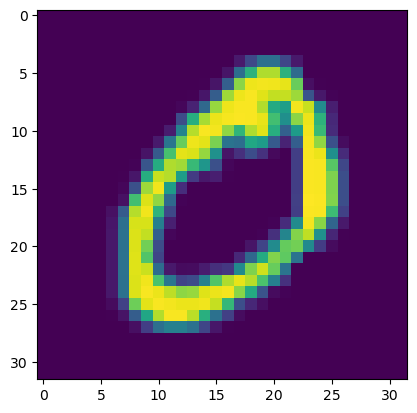

In [6]:
import matplotlib.pyplot as plt

x = dataloader.dataset[1][0].unsqueeze(0)
plt.imshow(x[0].permute(1, 2, 0))

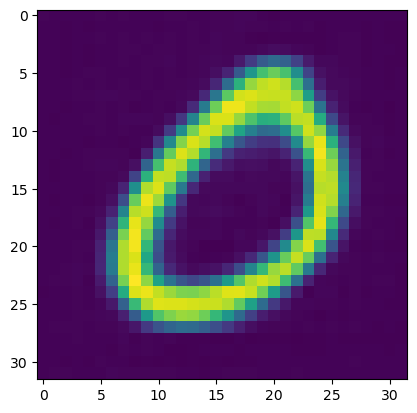

In [7]:
model.eval()

x = x.to(device)
mean, log_var = model.encoder(x)
z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
x_bar = model.decoder(z_sample)

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())

In [5]:
latent_images = []
labels = []

model.eval()
with torch.no_grad():
    for image, label in dataloader:
        image = image.to(device)
        mean, log_var = model.encoder(image)
        z = mean.to(device)
        latent_images.append(z)
        labels.append(label)

In [6]:
# Convertir listas a tensores
latent_images = torch.cat(latent_images)
labels = torch.cat(labels)

In [7]:
latent_images.shape, labels.shape

(torch.Size([60000, 5, 8, 8]), torch.Size([60000]))

In [8]:
from torch.utils.data import Dataset

class LatentDataset(Dataset):
    def __init__(self, latents, labels):
        self.latents = latents
        self.labels = labels

    def __len__(self):
        return len(self.latents)

    def __getitem__(self, idx):
        return self.latents[idx], self.labels[idx]

# Crear el dataset con las codificaciones latentes
latent_mnist_dataset = LatentDataset(latent_images, labels)

In [33]:
from torch.utils.data import DataLoader, Subset

# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_8 = [i for i, (img, label) in enumerate(latent_mnist_dataset) if label == 8]

# Crear un dataset con solo esos ejemplos (usando Subset)
latent_dataset_clase_8 = Subset(latent_mnist_dataset, indices_clase_8)

latent_dataloader = DataLoader(latent_dataset_clase_8, batch_size=32, shuffle=True)

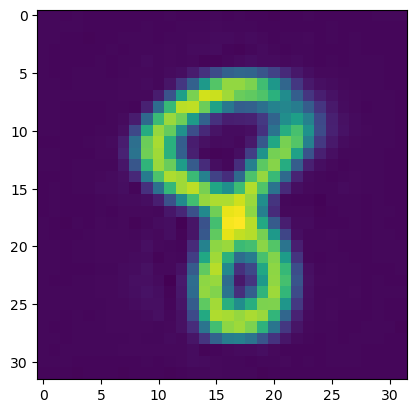

In [34]:
x_bar = model.decoder(latent_dataloader.dataset[0][0].unsqueeze(0))

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())

In [35]:
unet = Unet(image_channels = latent_images.shape[1], down_channels = [128, 256, 256, 256], mid_channels = [256, 256], time_emb_dim = 256,
            down_sample = [False, False, False], num_down_layers = 2, num_mid_layers = 2, num_up_layers = 2, 
            attn_down = [True, True, True], norm_channels = 32, num_heads = 16, conv_out_channels = 128).to(device)
optimizer = optim.AdamW(unet.parameters(), lr=0.00001)
mse = nn.MSELoss()
diffusion = Diffusion_Scheme(image_size = latent_images.shape[2], device = device, timesteps = 1000, beta1 = 0.0015, betaT = 0.0195, beta_scheme = "linear")

for epoch in range(epochs):
    prog_bar = tqdm(latent_dataloader)
    unet.train()
    loss_mean = 0.0
    for count, (images, _) in enumerate(prog_bar):
        images = images.to(device)
        t = diffusion.sample_timesteps(images.shape[0]).to(device)
        x_t, noise = diffusion.noise_images(images, t)
        predicted_noise = unet(x_t, t)
        loss = mse(noise, predicted_noise)
        loss_mean += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        prog_bar.set_postfix(MSE = loss_mean / (count+1))

100%|██████████| 183/183 [01:12<00:00,  2.53it/s, MSE=0.0141]


In [36]:
torch.save(unet.state_dict(), 'UNet_MNIST.pth')

In [12]:
diffusion = Diffusion_Scheme(image_size = latent_images.shape[2], device = device, timesteps = 1000, beta1 = 0.0015, betaT = 0.0195, beta_scheme = "linear")

unet = Unet(image_channels = latent_images.shape[1], down_channels = [128, 256, 256, 256], mid_channels = [256, 256], time_emb_dim = 256,
            down_sample = [False, False, False], num_down_layers = 2, num_mid_layers = 2, num_up_layers = 2, 
            attn_down = [True, True, True], norm_channels = 32, num_heads = 16, conv_out_channels = 128).to(device)

state_dict = torch.load('UNet_MNIST.pth')
unet.load_state_dict(state_dict)

/tmp/ipykernel_10684/493877418.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('UNet_MNIST.pth')


<All keys matched successfully>

In [37]:
# Generar una imagen en el espacio latente a partir de ruido aleatorio
z = diffusion.sampling(model = unet, num_channels = latent_images.shape[1], n = 10)

print(z.shape)

Sampleando 10 nuevas imágenes a partir del modelo entrenado...


999it [00:45, 22.13it/s]

torch.Size([10, 5, 8, 8])


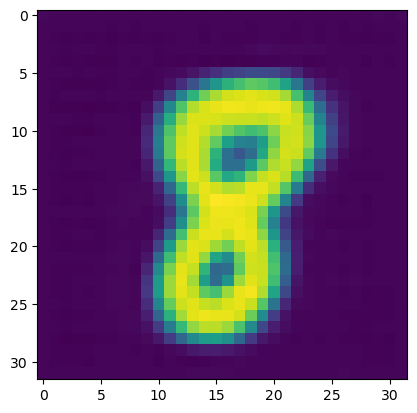

In [38]:
import matplotlib.pyplot as plt

model.eval()

x_bar = model.decoder(z)

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())

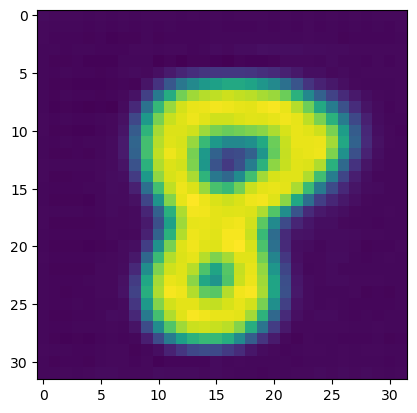

In [39]:
plt.imshow(x_bar[6].permute(1, 2, 0).cpu().detach().numpy())